#### DYNAMIC PRICING: OPTIMIZED PRICING STRATEGY USING MULTI-ARMED BANDIT THEORY

* Importing the required libraries

In [1]:
from pricing_simulation_pipeline import (
    DatabaseConnector,
    DataPreprocessor,
    ClusterAnalyzer,
    DemandModeler,
    PricingSimulator,
    Visualizer,
    RevenueComparer,
    SummaryGenerator
)
import pandas as pd

In [2]:
# Extracting the required data from SQL Database with optimized queries

db = DatabaseConnector(server='LAPTOP-CDFQR142', database='ContosoRetailDW')
sales, simulation, promotion = db.fetch_tables()

d:\Studies_Data_Science\Masters Project\pricing_simulation_pipeline.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales = pd.read_sql_query('SELECT DateKey, ProductKey, UnitPrice, DiscountAmount, SalesQuantity, ReturnQuantity, PromotionKey FROM FactOnlineSales', cnxn)
d:\Studies_Data_Science\Masters Project\pricing_simulation_pipeline.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  simulation = pd.read_sql_query('SELECT DateKey, ProductKey, UnitPrice, DiscountAmount, SalesQuantity, ReturnQuantity, PromotionKey FROM FactSales', cnxn)
d:\Studies_Data_Science\Masters Project\pricing_simulation_pipeline.py:51: UserWarning: pandas only supports SQLAlchemy connectable (en

In [3]:
# Cleaning the base data & the simulation data

sales = DataPreprocessor.clean_sales(sales)
aggregated_sales = DataPreprocessor.aggregate_sales(sales)

simulation = DataPreprocessor.clean_simulation(simulation)
aggregated_simulation = DataPreprocessor.aggregate_simulation(simulation)

promotion_table = DataPreprocessor.create_promotion_table(promotion)
aggregated_simulation = pd.merge(aggregated_simulation, promotion_table, on='PromotionKey', how='left')

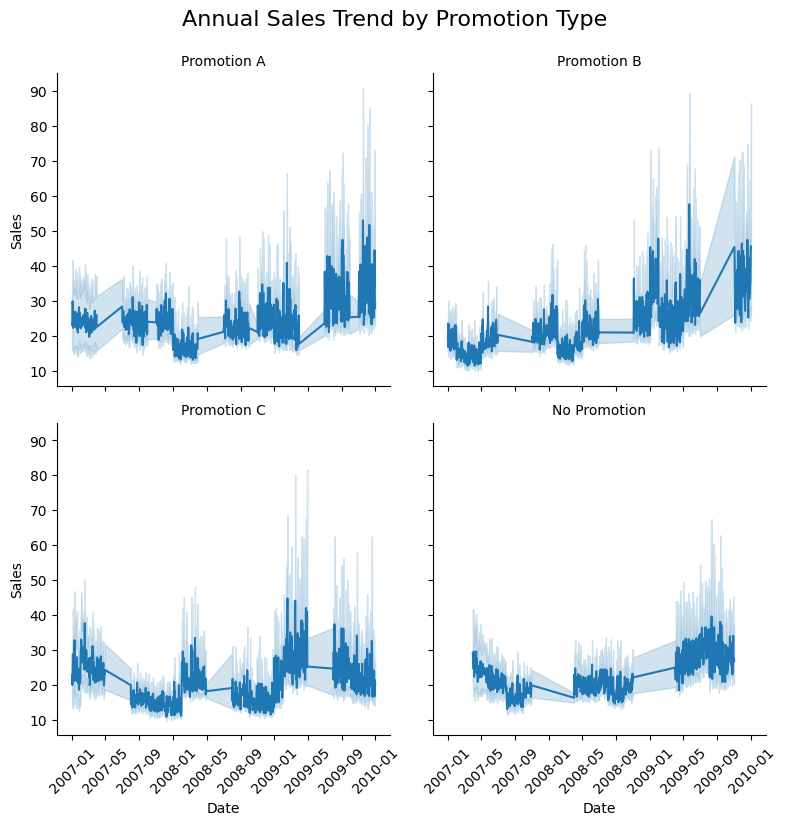

In [4]:
# Analyzing the historical sales

visual_data = pd.merge(aggregated_sales, promotion_table, on='PromotionKey', how='left')
Visualizer.plot_sales_trend(visual_data)

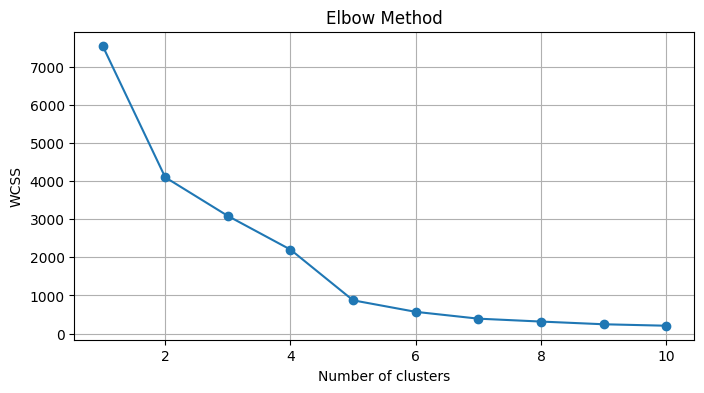

In [5]:
# Implementing the elbow method to find the optimal cluster number

product_summary = sales.groupby('ProductKey').agg({
    'UnitPrice': ['mean', 'std'],
    'SalesQuantity': 'sum'
}).reset_index()
product_summary.columns = ['ProductKey', 'AvgPrice', 'PriceStdDev', 'TotalSales']
product_summary = product_summary.fillna(0)

clusterer = ClusterAnalyzer()
wcss = clusterer.elbow_method(product_summary[['AvgPrice', 'PriceStdDev', 'TotalSales']])
Visualizer.plot_elbow(wcss)

* From the above plot, 5 seeems to be the optimal cluster number. Now based on this we'll go ahead and run a k-means clustering algorithm to group the products

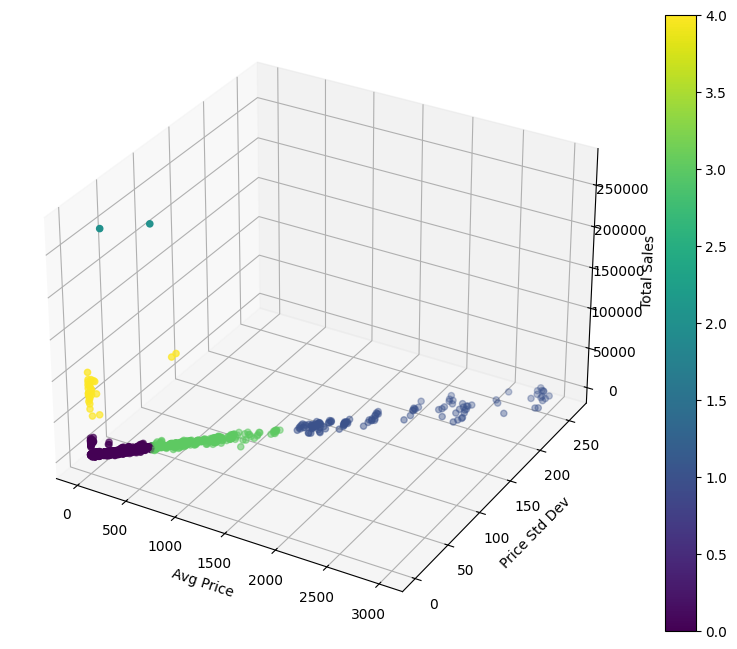

In [6]:
n_clusters = int(input("Select number of clusters based on elbow plot: "))
product_summary = clusterer.create_clusters(product_summary, n_clusters)
Visualizer.plot_3d_clusters(product_summary)

The above 3-D Scatter plot shows the output of the k-means algorithm, the product has been classified satisfactorily. Now we move on to cereating the demand functions.

#### Demand Functions Generation (Ridge/Arimax)

The user has the option to choose between either the ridge regression or arima time series model

In [7]:
model_choice = input("Choose model type (linear/arimax): ").lower()
merged_sales = pd.merge(aggregated_sales, promotion_table, on='PromotionKey', how='left')
modeler = DemandModeler(model_choice)
demand_model_df = modeler.fit_models(merged_sales, product_summary)
demand_model_df

,Cluster,PromotionType,Intercept,Coefficient_Price
0,0,No Promotion,18.147528,-0.010590
1,0,Promotion A,18.282802,-0.010953
2,0,Promotion B,18.700250,-0.013650
3,0,Promotion C,15.765826,-0.007620
4,4,No Promotion,152.515520,-0.035159
5,4,Promotion A,129.579889,0.023317
6,4,Promotion B,97.989540,-0.100039
7,4,Promotion C,109.844601,-0.017286
8,3,No Promotion,18.083409,-0.003286
9,3,Promotion A,21.206075,-0.007288


In [8]:
# Prepare the demand_functions dictionary
demand_functions = demand_model_df.set_index(['Cluster', 'PromotionType']).to_dict(orient='index')


### Multi Armed Bandit Algorithm: Learning & Earning Phase

In [9]:
phases = [
    ('2009-12-01', '2009-12-14'),  # Learning phase 1
    ('2009-12-04', '2009-12-10'),  # Earning phase 1
    ('2009-12-11', '2009-12-24'),  # Learning phase 2
    ('2009-12-25', '2009-12-31')   # Earning phase 2
]

simulator = PricingSimulator(phases=phases, demand_functions=demand_functions)
pricing_results_df = simulator.simulate(aggregated_simulation, product_summary)


#### The Dynamic Pricing algorithm has selected the below mentioned items for price decrease.

In [ ]:
summary_table = SummaryGenerator.generate_summary(pricing_results_df)
summary_table.head(10)

,ProductKey,UniquePricesUsed,EarningPhaseRevenue,OptimalHindsightRevenue,Regret
2513,179,"[90.14249999999998, 86.6842652489496]",39583.89,48970.07,9386.18
2116,1599,"[32.98419156345042, 46.10123566878981]",15521.69,26388.73,10867.04
2182,89,"[117.11681503663512, 118.40921078947369]",61896.48,73632.37,11735.89
1993,1447,"[243.07281195079085, 231.74624425497686]",56041.89,68172.89,12131.00
1341,2045,"[146.45068692810457, 117.11681503663512]",41404.58,53604.60,12200.02
231,681,"[98.21429853181077, 86.6842652489496]",54365.03,67219.33,12854.29
1837,2056,"[160.27268771929826, 117.11681503663512]",35773.23,49797.87,14024.64
1109,962,"[147.54936482432063, 151.78399358460305]",37615.25,51653.40,14038.15
2181,88,"[121.20782803030302, 86.6842652489496]",66819.40,81677.53,14858.13
1988,1430,"[242.30200325732898, 238.84701418737768]",97356.79,113853.20,16496.41


#### Below analysis shows the comparison of revenue of a user selected product based on different pricing techniques.

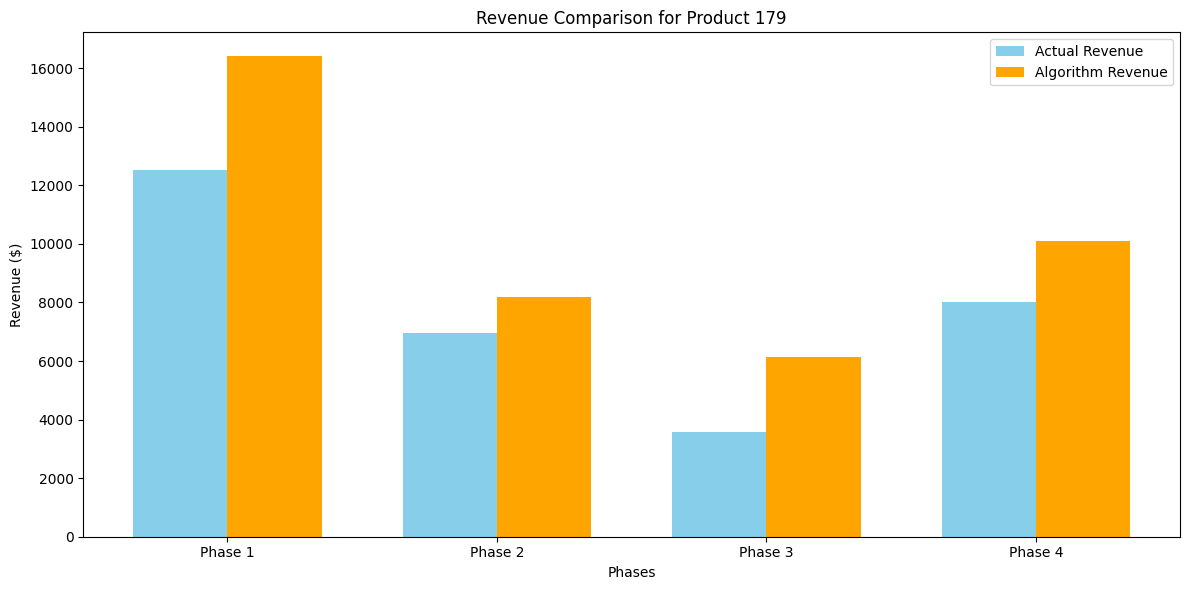

In [11]:
RevenueComparer.compare_product(pricing_results_df, aggregated_simulation, phases)